In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import datetime as dt

import mplfinance as mpf

import talib

from sklearn.ensemble import GradientBoostingClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier 

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

%matplotlib inline

Загружаем исходные данные

In [2]:
TRAIN_START_DATE = '2009-01-01'
TRAIN_END_DATE = '2019-01-01'
TEST_START_DATE = '2019-01-01'
TEST_END_DATE = '2021-01-01'


Преобразуем дату и сортируем датасет по дате и бумагам

In [36]:
data = pd.read_csv('data/AAPL.csv')
data['date'] = pd.to_datetime(data['date'],format='%Y-%m-%d')
data.set_index(data['date'], inplace=True)
data.head()

,date,close,high,low,open,volume
date,,,,,,
2009-01-02,2009-01-02,2.727417,2.736134,2.559415,2.581054,746015200
2009-01-05,2009-01-05,2.842525,2.890612,2.786323,2.800149,1181608400
2009-01-06,2009-01-06,2.795640,2.920365,2.776706,2.883699,1289310400
2009-01-07,2009-01-07,2.735232,2.780012,2.712691,2.759276,753048800
2009-01-08,2009-01-08,2.786023,2.799548,2.706079,2.717800,673500800


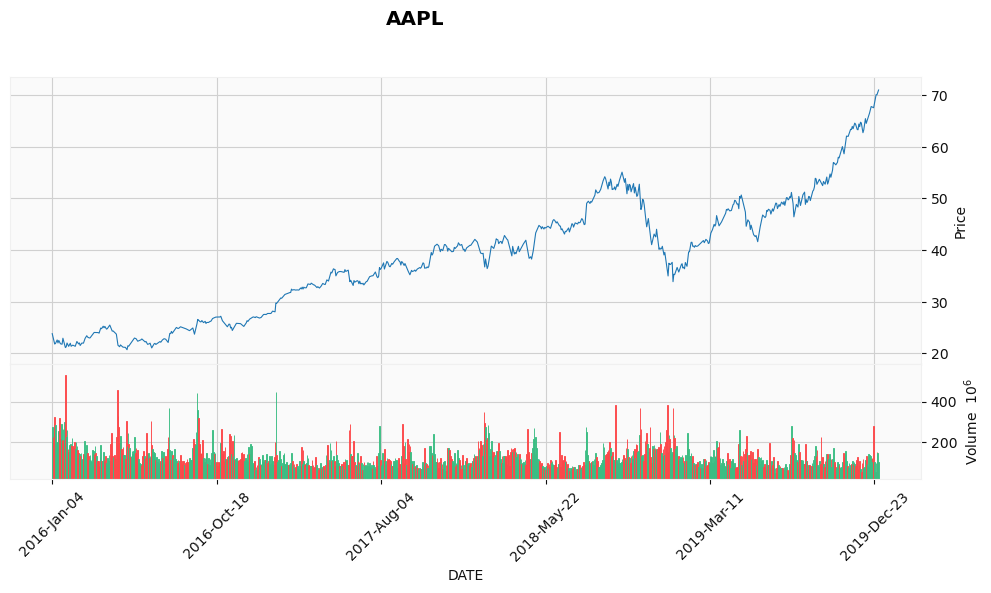

In [38]:
mpf.plot(data.loc[(data.index.year >= 2016) & (data.index.year < 2020)],
         volume=True,
         style='yahoo',
         type='line',
         figratio=(22,10),
         title='AAPL',
         ylabel='Price',
        #  savefig='../Presentation/img/volume.png',
         xlabel='DATE')

## Технический анализ

Будем формировать показатели с использованием библиотеки TA-Lib (https://ta-lib.org)

Сколько всего индикаторов есть в библиотеке TA-Lib

In [39]:
len(talib.get_functions())

158

In [40]:
talib.get_functions()

['HT_DCPERIOD',
 'HT_DCPHASE',
 'HT_PHASOR',
 'HT_SINE',
 'HT_TRENDMODE',
 'ADD',
 'DIV',
 'MAX',
 'MAXINDEX',
 'MIN',
 'MININDEX',
 'MINMAX',
 'MINMAXINDEX',
 'MULT',
 'SUB',
 'SUM',
 'ACOS',
 'ASIN',
 'ATAN',
 'CEIL',
 'COS',
 'COSH',
 'EXP',
 'FLOOR',
 'LN',
 'LOG10',
 'SIN',
 'SINH',
 'SQRT',
 'TAN',
 'TANH',
 'ADX',
 'ADXR',
 'APO',
 'AROON',
 'AROONOSC',
 'BOP',
 'CCI',
 'CMO',
 'DX',
 'MACD',
 'MACDEXT',
 'MACDFIX',
 'MFI',
 'MINUS_DI',
 'MINUS_DM',
 'MOM',
 'PLUS_DI',
 'PLUS_DM',
 'PPO',
 'ROC',
 'ROCP',
 'ROCR',
 'ROCR100',
 'RSI',
 'STOCH',
 'STOCHF',
 'STOCHRSI',
 'TRIX',
 'ULTOSC',
 'WILLR',
 'BBANDS',
 'DEMA',
 'EMA',
 'HT_TRENDLINE',
 'KAMA',
 'MA',
 'MAMA',
 'MAVP',
 'MIDPOINT',
 'MIDPRICE',
 'SAR',
 'SAREXT',
 'SMA',
 'T3',
 'TEMA',
 'TRIMA',
 'WMA',
 'CDL2CROWS',
 'CDL3BLACKCROWS',
 'CDL3INSIDE',
 'CDL3LINESTRIKE',
 'CDL3OUTSIDE',
 'CDL3STARSINSOUTH',
 'CDL3WHITESOLDIERS',
 'CDLABANDONEDBABY',
 'CDLADVANCEBLOCK',
 'CDLBELTHOLD',
 'CDLBREAKAWAY',
 'CDLCLOSINGMARUBOZU',


Какие группы индикаторы есть в библиотеке TA-Lib

In [41]:
list(talib.get_function_groups().keys())

['Cycle Indicators',
 'Math Operators',
 'Math Transform',
 'Momentum Indicators',
 'Overlap Studies',
 'Pattern Recognition',
 'Price Transform',
 'Statistic Functions',
 'Volatility Indicators',
 'Volume Indicators']

Посмотрм на индикаторы определенной группы

In [42]:
talib.get_function_groups()['Volatility Indicators']

['ATR', 'NATR', 'TRANGE']

### Простое скользящее среднее (Simple Moving Averages - SMA)

Скользящие средние - один из самых популярных технических индикаторов, используемых для сглаживания ценовых колебаний и выявления трендов. Они могут рассчитываться с использованием различных временных периодов, таких как краткосрочный (10 дней), среднесрочный (50 дней) и долгосрочный (200 дней).

50-дневная SMA/EMA: Один из наиболее популярных периодов, используется для анализа среднесрочных трендов и часто применяется в сочетании с 200-дневной SMA для выявления "золотого пересечения" (golden cross) и "мёртвого пересечения" (death cross).

In [43]:
data["sma_5"] = talib.SMA(data["close"], timeperiod=5)
data["sma_10"] = talib.SMA(data["close"], timeperiod=10)
data["sma_15"] = talib.SMA(data["close"], timeperiod=15)
data["sma_20"] = talib.SMA(data["close"], timeperiod=20)
data["sma_50"] = talib.SMA(data["close"], timeperiod=50)
data["sma_200"] = talib.SMA(data["close"], timeperiod=200)
data["sma_ratio_5_15"] = data['sma_15'] / data['sma_5']
data["sma_ratio_10_50"] = data['sma_50'] / data['sma_15']
data['sma_5_Volume'] = talib.SMA(data["volume"], timeperiod=5)
data['sma_10_Volume'] = talib.SMA(data["volume"], timeperiod=10)
data['sma_15_Volume'] = talib.SMA(data["volume"], timeperiod=15)
data['sma_50_Volume'] = talib.SMA(data["volume"], timeperiod=50)
data["sma_Volume_ratio_5_15"] = data['sma_5_Volume'] / data['sma_15_Volume']
data["sma_Volume_ratio_10_50"] = data['sma_10_Volume'] / data['sma_50_Volume']

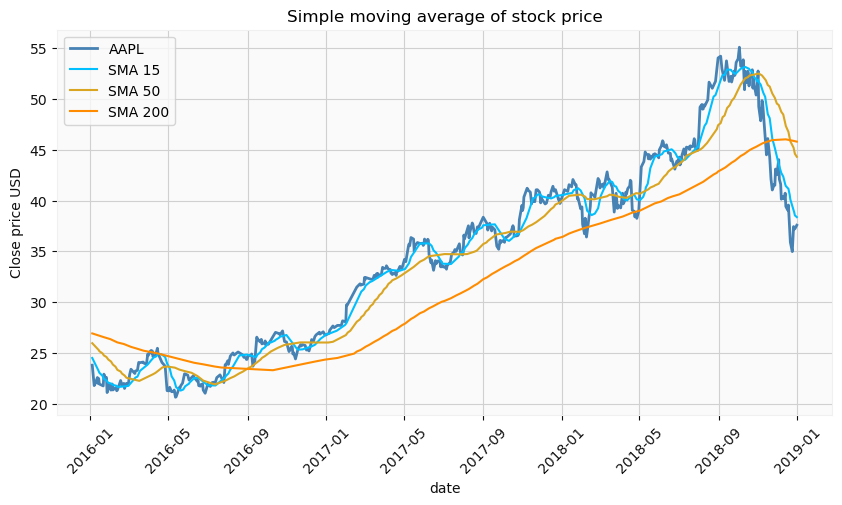

In [51]:
start_day = dt.datetime(2016, 1, 1)
end_day = dt.datetime(2019, 1, 1)
plt.figure(figsize=(10, 5))
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['close'], 
         linestyle='-', linewidth=2, color='steelblue', label='AAPL')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['sma_15'], 
         linestyle='-', color='deepskyblue', label='SMA 15')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['sma_50'], 
         linestyle='-', color='goldenrod', label='SMA 50')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['sma_200'], 
         linestyle='-', color='darkorange', label='SMA 200')
plt.title('Simple moving average of stock price')
plt.xlabel('date')
plt.xticks(rotation=45)
plt.ylabel('Close price USD')
plt.legend()
# plt.savefig('img/sma.png')
plt.show()

In [52]:
data["ema_5"] = talib.EMA(data["close"], timeperiod=5)
data["ema_10"] = talib.EMA(data["close"], timeperiod=10)
data["ema_20"] = talib.EMA(data["close"], timeperiod=20)
data["ema_50"] = talib.EMA(data["close"], timeperiod=50)
data["ema_200"] = talib.EMA(data["close"], timeperiod=200)

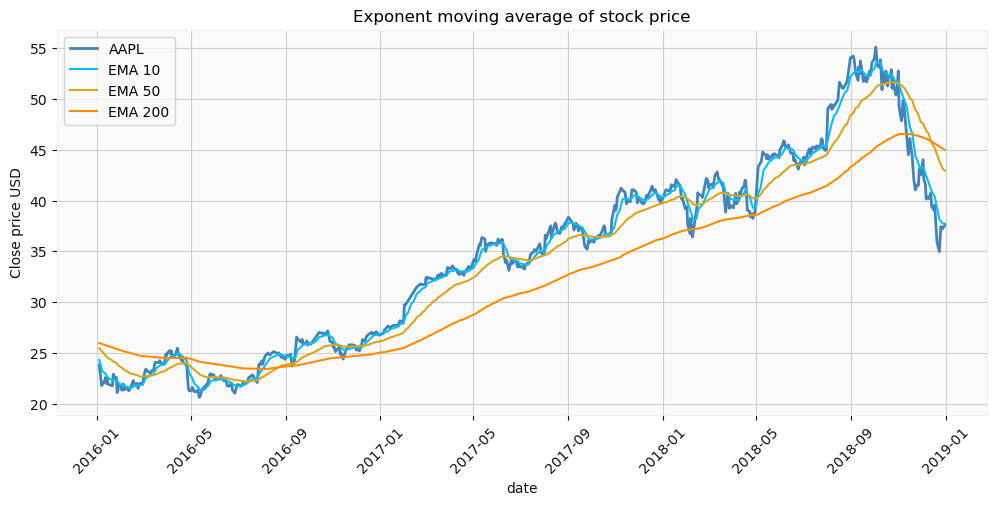

In [53]:
start_day = dt.datetime(2016, 1, 1)
end_day = dt.datetime(2019, 1, 1)
plt.figure(figsize=(12, 5))
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['close'], 
         linestyle='-', linewidth=2, color='steelblue', label='AAPL')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['ema_10'], 
         linestyle='-', color='deepskyblue', label='EMA 10')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['ema_50'], 
         linestyle='-', color='goldenrod', label='EMA 50')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['ema_200'], 
         linestyle='-', color='darkorange', label='EMA 200')
plt.title('Exponent moving average of stock price')
plt.xlabel('date')
plt.xticks(rotation=45)
plt.ylabel('Close price USD')
plt.legend()
# plt.savefig('img/ema.png')
plt.show()

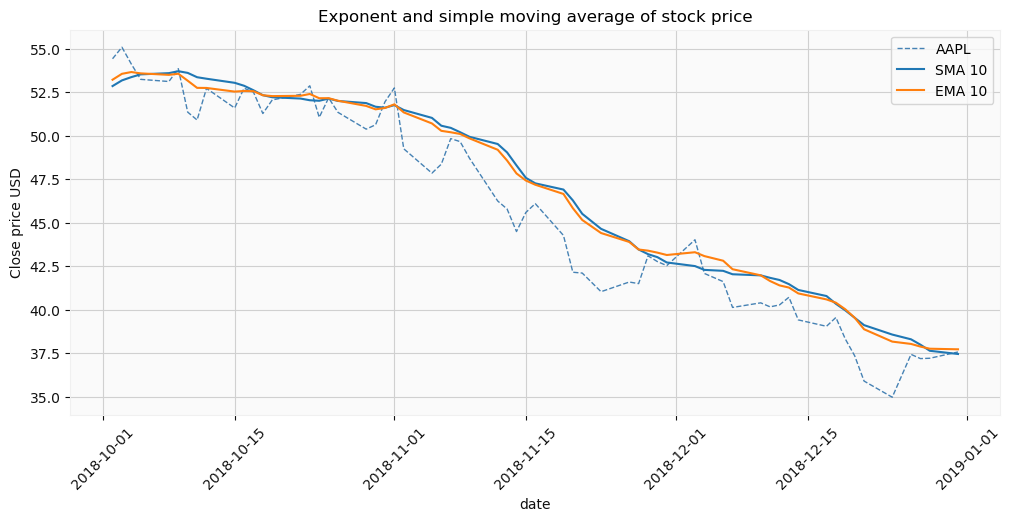

In [54]:
start_day = dt.datetime(2018, 10, 1)
end_day = dt.datetime(2019, 1, 1)
plt.figure(figsize=(12, 5))
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['close'], 
         linestyle='--', linewidth=1, color='steelblue', label='AAPL')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['sma_10'], 
         linestyle='-', label='SMA 10')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['ema_10'], 
         linestyle='-', label='EMA 10')
plt.title('Exponent and simple moving average of stock price')
plt.xlabel('date')
plt.xticks(rotation=45)
plt.ylabel('Close price USD')
plt.legend()
plt.show()

### Полосы Боллинджера (Bollinger Bands)

Полосы Боллинджера используются для измерения волатильности актива и выявления условий перекупленности и перепроданности. Полосы состоят из скользящей средней (обычно 20-дневной скользящей средней) и двух линий стандартного отклонения выше и ниже скользящей средней.

#### Идентификация волатильности:
- Когда полосы расширяются/сужаются, это указывает на увеличение/снижение волатильности.
#### Сигналы на покупку и продажу:
- Когда цена актива пересекает верхнюю полосу, это может быть сигналом перекупленности и возможного разворота вниз.
- Когда цена актива пересекает нижнюю полосу, это может быть сигналом перепроданности и возможного разворота вверх.
#### Торговля на отскок:
- Трейдеры могут использовать полосы Боллинджера для торговли на отскок, покупая, когда цена касается нижней полосы, и продавая, когда она касается верхней полосы.
#### Подтверждение трендов:
- Если цена постоянно прикасается к верхней полосе в восходящем тренде или к нижней полосе в нисходящем тренде, это может служить подтверждением силы текущего тренда.


In [55]:
# Calculate the Bollinger Bands
data["upper_band"], data["middle_band"], data["lower_band"] = talib.BBANDS(data["close"], timeperiod=20)

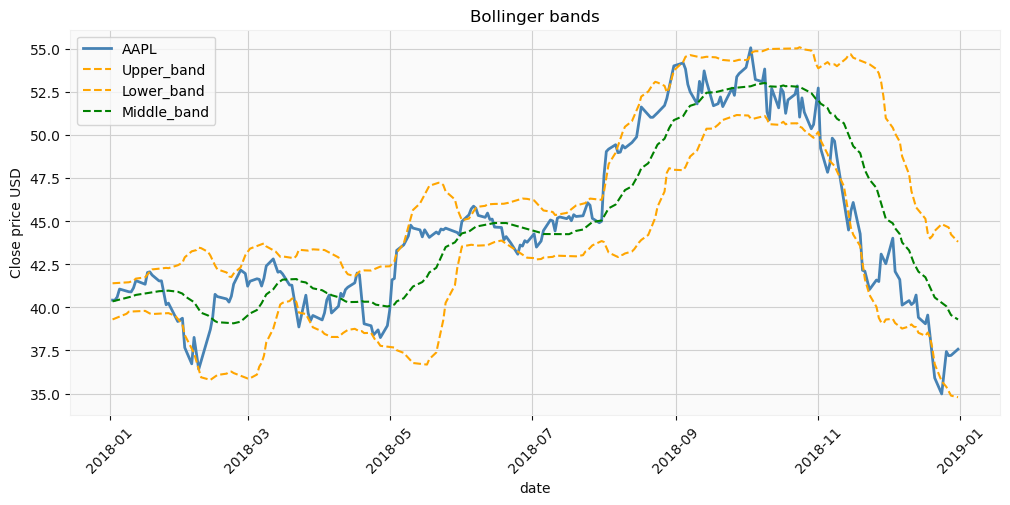

In [57]:
start_day = dt.datetime(2018, 1, 1)
end_day = dt.datetime(2019, 1, 1)
plt.figure(figsize=(12, 5))
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['close'], 
         linestyle='-', linewidth=2, color='steelblue', label='AAPL')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['upper_band'], 
         linestyle='--', color='orange', label='Upper_band')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['lower_band'], 
         linestyle='--', color='orange', label='Lower_band')
plt.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['middle_band'], 
         linestyle='--', color='green', label='Middle_band')
plt.title('Bollinger bands')
plt.xlabel('date')
plt.xticks(rotation=45)
plt.ylabel('Close price USD')
plt.legend()
plt.show()

### Индекс относительной силы (Relative Strength Index - RSI)

RSI - это индикатор импульса, который сравнивает величину недавних достижений с недавними потерями, чтобы определить условия перекупленности и перепроданности. Обычно он используется с 14-дневным периодом.

#### Идентификация волатильности:
- Когда полосы расширяются/сужаются, это указывает на увеличение/снижение волатильности.
#### Определение перекупленности и перепроданности:
- Когда RSI выше 70, это может указывать на перекупленность актива, и трейдеры могут рассматривать возможность продажи.
- Когда RSI ниже 30, это может указывать на перепроданность актива, и трейдеры могут рассматривать возможность покупки.
#### Сигналы на пересечении:
- Некоторые трейдеры используют пересечение уровня 50 в RSI как сигнал на покупку или продажу. Когда RSI пересекает уровень 50 сверху вниз, это может быть сигналом на продажу, и наоборот.


In [59]:
# Calculate the relative strength index (RSI)
data["RSI"] = talib.RSI(data["close"], timeperiod=14)

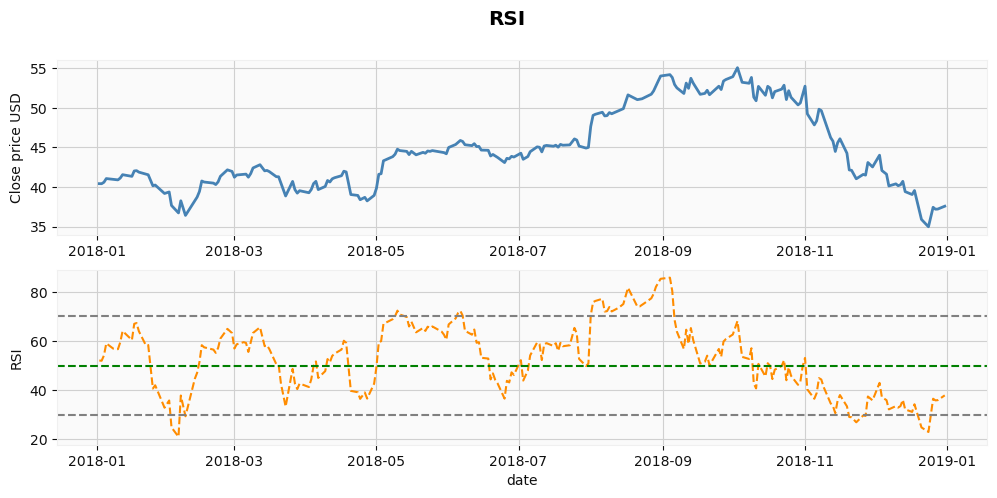

In [60]:
start_day = dt.datetime(2018, 1, 1)
end_day = dt.datetime(2019, 1, 1)

fig, axs = plt.subplots(2, figsize=(12, 5))

axs[0].plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['close'], 
         linestyle='-', linewidth=2, color='steelblue', label='AAPL')
axs[1].plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['RSI'], 
         linestyle='--', color='darkorange', label='RSI')
axs[1].axhline(y=30, color='grey', linestyle='--')
axs[1].axhline(y=70, color='grey', linestyle='--')
axs[1].axhline(y=50, color='green', linestyle='--')

axs[1].set_xlabel('date')
axs[0].set_ylabel('Close price USD')
axs[1].set_ylabel('RSI')

fig.suptitle('RSI')
plt.show()

### Дивергенция сходимости скользящих средних (Moving Average Convergence Divergence - MACD)

MACD - это индикатор следования за трендом, который измеряет разницу между краткосрочной скользящей средней и долгосрочной скользящей средней. Обычно он используется с 12-дневной и 26-дневной скользящей средней, а также с 9-дневной сигнальной линией.

#### Пересечение MACD и сигнальной линии:
- Когда линия MACD пересекает сигнальную линию снизу вверх, это считается бычьим сигналом на покупку.
- Когда линия MACD пересекает сигнальную линию сверху вниз, это считается медвежьим сигналом на продажу.
#### Положение линии MACD относительно нулевой линии:
- Когда линия MACD находится выше нулевой линии, это указывает на восходящий тренд.
- Когда линия MACD находится ниже нулевой линии, это указывает на нисходящий тренд.


In [61]:
# Calculate the MACD
data["macd"], data["macd_signal"], data["macd_hist"] = talib.MACD(data["close"], fastperiod=12, slowperiod=26, signalperiod=9)

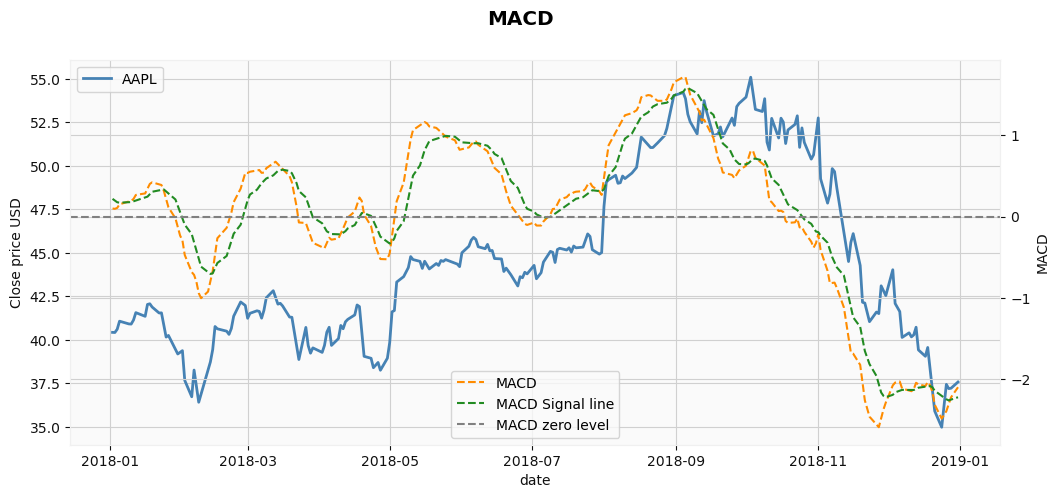

In [63]:
start_day = dt.datetime(2018, 1, 1)
end_day = dt.datetime(2019, 1, 1)

fig, ax = plt.subplots(figsize=(12, 5))

ax2 = ax.twinx()

ax.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['close'], 
         linestyle='-', linewidth=2, color='steelblue', label='AAPL')
ax2.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['macd'], 
         linestyle='--', color='darkorange', label='MACD')
ax2.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['macd_signal'], 
         linestyle='--', color='forestgreen', label='MACD Signal line')
ax2.axhline(y=0, color='grey', linestyle='--', label='MACD zero level')

ax.set_xlabel('date')
ax.set_ylabel('Close price USD')
ax2.set_ylabel('MACD')

fig.suptitle('MACD', fontweight="bold")
ax.legend(loc='upper left')
ax2.legend(loc='lower center')
plt.show()

### Индекс средней направленности (ADX)

Индекс средней направленности был разработан Уайлдером для оценки силы тренда в ценах на акции. 

Два его основных компонента, +DI и -DI, помогают определить направление тренда. ADX указывает только на силу тренда, но не его направление.

#### Сила тренда:
- Значения выше 25 указывают на сильный тренд.
- Значения ниже 20 указывают на слабый тренд.


In [64]:
data['ADX_5'] = talib.ADX(data['high'], data['low'], data['close'], timeperiod=5)
data['ADX_15'] = talib.ADX(data['high'], data['low'], data['close'], timeperiod=15)

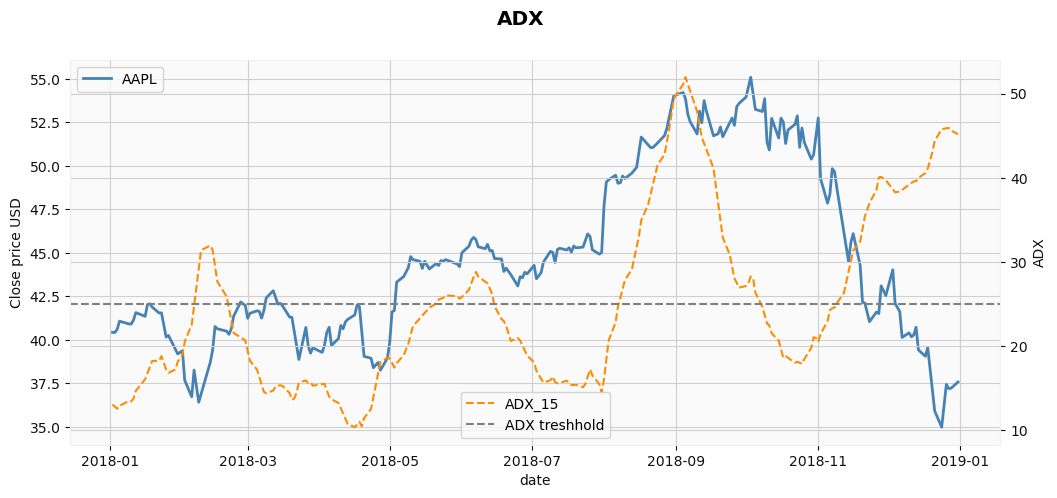

In [65]:
start_day = dt.datetime(2018, 1, 1)
end_day = dt.datetime(2019, 1, 1)

fig, ax = plt.subplots(figsize=(12, 5))

ax2 = ax.twinx()

ax.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['close'], 
         linestyle='-', linewidth=2, color='steelblue', label='AAPL')
ax2.plot(data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['date'], 
         data.loc[(data['date'] < end_day) & (data['date'] > start_day)]['ADX_15'], 
         linestyle='--', color='darkorange', label='ADX_15')
ax2.axhline(y=25, color='grey', linestyle='--', label='ADX treshhold')

ax.set_xlabel('date')
ax.set_ylabel('Close price USD')
ax2.set_ylabel('ADX')

fig.suptitle('ADX', fontweight="bold")
ax.legend(loc='upper left')
ax2.legend(loc='lower center')
plt.show()